# Student Grade Analysis
This notebook explores the student performance dataset to understand factors impacting final grades. We will clean the data, answer key analysis questions, and visualize the results.

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Print the folder Jupyter is currently looking at
current_folder = os.getcwd()
print(f"Jupyter is looking for files in: {current_folder}")
print("Please make sure your CSV file is saved in this exact folder!\n")

# 1. Load Dataset (Change 'student-por.csv' to 'student-mat.csv' if needed)
# Using sep=';' because the data is separated by semicolons
file_name = 'student-por.csv' 

try:
    df = pd.read_csv(file_name, sep=';')
    print("* File loaded successfully!")
except FileNotFoundError:
    print(f"** ERROR: Could not find '{file_name}'.")
    print(f"Please copy the file into: {current_folder}")

Jupyter is looking for files in: C:\Users\user
Please make sure your CSV file is saved in this exact folder!

* File loaded successfully!


## 2. Explore & Clean Data
We inspect the dataset's shape and data types, check for missing values, and remove any duplicate rows.

In [4]:
if 'df' in locals():
    print("--- Initial Dataset Shape ---")
    print(df.shape)

    print("\n--- Data Types ---")
    print(df.dtypes.head()) # Showing just the first few for brevity

    print("\n--- Missing Values ---")
    print(df.isnull().sum().sum(), "total missing values")

    # Remove duplicates
    df = df.drop_duplicates()

    print("\n--- Dataset Shape after dropping duplicates ---")
    print(df.shape)

--- Initial Dataset Shape ---
(649, 33)

--- Data Types ---
school     object
sex        object
age         int64
address    object
famsize    object
dtype: object

--- Missing Values ---
0 total missing values

--- Dataset Shape after dropping duplicates ---
(649, 33)


## 3. Analysis Questions
Calculating specific metrics: average final grade (G3), number of top scorers, correlation between study time and performance, and gender differences.

In [5]:
if 'df' in locals():
    # Average final grade (G3)
    avg_g3 = df['G3'].mean()
    print(f"Average final grade (G3): {avg_g3:.2f}")

    # How many students scored above 15?
    high_scorers = df[df['G3'] > 15]
    print(f"Number of students who scored above 15: {len(high_scorers)}")

    # Is study time correlated with performance?
    study_corr = df['studytime'].corr(df['G3'])
    print(f"Correlation between study time and final grade: {study_corr:.4f}")

    # Which gender performs better on average?
    gender_avg = df.groupby('sex')['G3'].mean()
    print("\nAverage grade by gender:")
    print(gender_avg)

Average final grade (G3): 11.91
Number of students who scored above 15: 82
Correlation between study time and final grade: 0.2498

Average grade by gender:
sex
F    12.253264
M    11.406015
Name: G3, dtype: float64


## 4. Visualizations
Visualizing the distribution of grades, the relationship between study time and grades, and average scores by gender.

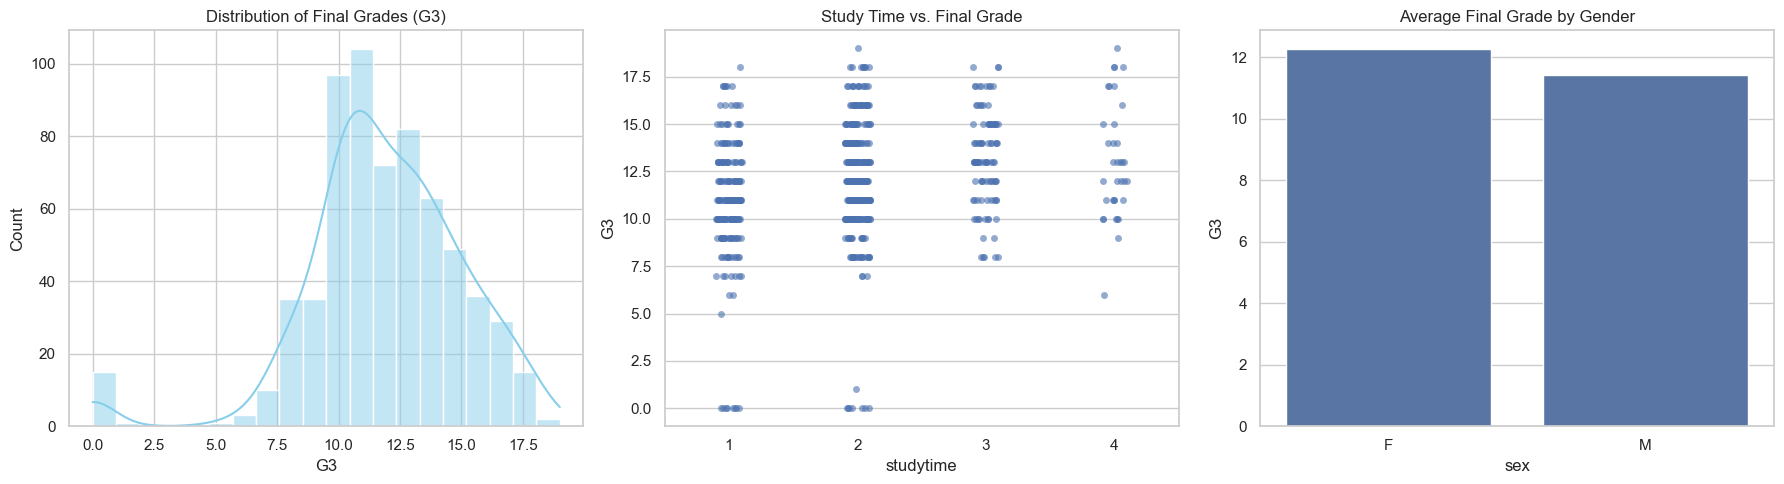

In [6]:
if 'df' in locals():
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Histogram of grades
    sns.histplot(df['G3'], bins=20, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title('Distribution of Final Grades (G3)')

    # 2. Scatterplot: study time vs grades (using stripplot for better visibility)
    sns.stripplot(x='studytime', y='G3', data=df, ax=axes[1], alpha=0.6, jitter=True)
    axes[1].set_title('Study Time vs. Final Grade')

    # 3. Bar chart: male vs female average score
    sns.barplot(x='sex', y='G3', data=df, ax=axes[2], estimator='mean', errorbar=None)
    axes[2].set_title('Average Final Grade by Gender')

    plt.tight_layout()
    plt.show()